In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import geopandas as gpd
from shapely import Polygon
import ee, geemap
import geemap.colormaps as cm

In [2]:
from hsa.compute import make_local_dask_client
client = make_local_dask_client(n_workers=6,
                                threads_per_worker=2,
                                local_directory='dask-tmp')
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 6
Total threads: 12,Total memory: 7.54 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33681,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36341,Total threads: 2
Dashboard: http://127.0.0.1:33081/status,Memory: 1.26 GiB
Nanny: tcp://127.0.0.1:38899,


In [3]:
from hsa.movement.geometry import prepare_trajectory_data
df = pd.read_csv("data/relocations/pango-large-subset.csv")
reloc = prepare_trajectory_data(df, geometry_col="geometry", source_crs = "EPSG:32733", target_crs = "EPSG:32733")

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
count = reloc["Individual_ID"].value_counts().reset_index()
sns.barplot(count, x = "Individual_ID", y = "count", hue = "Individual_ID", ax=ax)
plt.xticks(rotation=90)
plt.show()

In [ ]:
EE_PROJECT = 'test-with-greta'  # change if needed
TARGET_CRS = 'EPSG:32733'
EXPORT_SCALE = 30
BUFFER_M = 0

SHAPES = Path('data/vectors')
PERIMETER_FILE = SHAPES / 'onr_perimeter.shp'
OUT_ZARR = Path('env_32733.zarr')

START = reloc["Timestamp"].min()
END = reloc["Timestamp"].max()

In [ ]:
from hsa.remote_sensing import initialize_earth_engine
e = initialize_earth_engine(project=EE_PROJECT)

perimeter_raw = gpd.read_file(PERIMETER_FILE, engine='pyogrio')
perimeter = gpd.GeoDataFrame(
    geometry=[Polygon(perimeter_raw.geometry.iloc[0])],
    crs=perimeter_raw.crs,
).to_crs(TARGET_CRS)

aoi = gpd.GeoDataFrame(geometry=perimeter.geometry.buffer(BUFFER_M), crs=TARGET_CRS)
aoi_wgs84 = aoi.to_crs('EPSG:4326')
aoi_ee = geemap.geopandas_to_ee(aoi_wgs84)

def reset_map():
    Map = geemap.Map()
    Map.addLayer(aoi_ee, {}, "AOI")
    Map.centerObject(aoi_ee, zoom = 10)
    return Map

In [ ]:
def mask_s2_clouds(image):
    qa = image.select("QA60")

    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11

    mask = (
        qa.bitwiseAnd(cloud_bit_mask).eq(0)
        .And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    )

    optical = (
        image.updateMask(mask)
        .select(
            ["B2", "B3", "B4", "B8", "B11", "B12"],
            ["blue", "green", "red", "nir", "swir1", "swir2"],
        )
        .divide(10000)
    )

    return optical.copyProperties(image, ["system:time_start"])

In [ ]:
def add_water_index(image):
    mndwi = image.normalizedDifference(["green", "swir1"]).rename("mndwi")
    return image.addBands(mndwi)

In [ ]:
s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi_ee.geometry())
    .filterDate(START, END)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    .map(mask_s2_clouds)
    .map(add_water_index)
)

In [ ]:
mndwi_water = s2.select("mndwi").max().clip(aoi_ee)

Map = reset_map()
Map.addLayer(mndwi_water, {"min": 0, "max": 1, "palette": cm.palettes.Blues}, "MNDWI")
Map.addLayer(mndwi_water.gt(0.6))
Map

In [ ]:
water = mndwi_water.gt(0.6)
land_mask = water.Not()

In [ ]:
# Sentinel-1
s1 = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filter(ee.Filter.eq("instrumentMode", "IW"))
    .filter(ee.Filter.eq("orbitProperties_pass", "ASCENDING"))
    .filterDate(START, END)
    .filterBounds(aoi_ee.geometry())
)

In [ ]:
# ---------------------
# Calculate S1 Indices
# ---------------------
def add_s1_indices(image):

    vv = image.select("VV")
    vh = image.select("VH")

    vv_vh_diff = vv.subtract(vh).rename("vv_vh_diff")

    vv_lin = ee.Image(10).pow(vv.divide(10)).rename("vv_linear")
    vh_lin = ee.Image(10).pow(vh.divide(10)).rename("vh_linear")

    vv_vh_ratio = vv_lin.divide(vh_lin).rename("vv_vh_ratio")

    return image.addBands([
        vv_vh_diff,
        vv_lin,
        vh_lin,
        vv_vh_ratio,
    ])

s1 = s1.map(add_s1_indices)

In [ ]:
def add_s2_indices(image):
    ndvi = image.normalizedDifference(["nir", "red"]).rename("ndvi")
    ndmi = image.normalizedDifference(["nir", "swir1"]).rename("ndmi")
    mndwi = image.normalizedDifference(["green", "swir1"]).rename("mndwi")

    bsi = (
        image.select("swir1").add(image.select("red"))
        .subtract(image.select("nir")).subtract(image.select("blue"))
        .divide(
            image.select("swir1").add(image.select("red"))
            .add(image.select("nir")).add(image.select("blue"))
        )
        .rename("bsi")
    )

    savi = (
        image.select("nir").subtract(image.select("red"))
        .multiply(1.5)
        .divide(image.select("nir").add(image.select("red")).add(0.5))
        .rename("savi")
    )

    return image.addBands([ndvi, ndmi, mndwi, bsi, savi])

s2 = s2.map(add_s2_indices)

In [ ]:
Map = reset_map()
Map

In [ ]:
vv_median = s1.select("VV").median().clip(aoi_ee)
vh_median = s1.select("VH").median().clip(aoi_ee)
vv_vh_diff_median = s1.select("vv_vh_diff").median().clip(aoi_ee)

Map.addLayer(
    ee.Image.cat([vv_median, vh_median, vv_vh_diff_median]),
    {
        "bands": ["VV", "VH", "vv_vh_diff"],
        "min": [-18, -25, 2],
        "max": [-5, -12, 12],
    },
    "S1 False Color Composite")

red = s2.select("red").median().clip(aoi_ee)
green = s2.select("green").median().clip(aoi_ee)
blue = s2.select("blue").median().clip(aoi_ee)

Map.addLayer(
    ee.Image.cat([red, green, blue]),
    {
        "bands": ["red", "green", "blue"],
        "min": 0.02,
        "max": 0.35,
    },
    "S2 True Colour Composite"
)

In [ ]:
Map.addLayer(s1.select("vv_vh_ratio").median().clip(aoi_ee), {"min": 1, "max": 8, "palette": cm.palettes.inferno}, "VV/VH")
Map.addLayer(s2.select("ndvi").median().clip(aoi_ee), {"min": 0, "max": 0.55, "palette": cm.palettes.Greens}, "NDVI")
Map.addLayer(s2.select("savi").median().clip(aoi_ee), {"min": 0, "max": 0.55, "palette": cm.palettes.Greens}, "SAVI")
Map.addLayer(s2.select("bsi").median().clip(aoi_ee), {"min": -0.5, "max": 0.5, "palette": cm.palettes.hot}, "BSI")

In [ ]:
# ------------------------------------------------------------
# Compositional layer from Sentinel-1 VH
# ------------------------------------------------------------

ndvi_30m = s2.select("ndvi").median().updateMask(land_mask).rename("ndvi_30m")

ndvi_100m = (
    s2.select("ndvi").median()
    .updateMask(land_mask)
    .focal_mean(radius=100, units="meters")
    .rename("ndvi_mean_100m")
)

ndvi_250m = (
    s2.select("ndvi").median()
    .updateMask(land_mask)
    .focal_mean(radius=250, units="meters")
    .rename("ndvi_mean_250m")
)

ndvi_stack = ee.Image.cat([ndvi_30m, ndvi_100m, ndvi_250m])

In [ ]:
# ------------------------------------------------------------
# SAR structural edge layer from Sentinel-1 VH
# ------------------------------------------------------------

def make_vh_edge_layers(vh, land_mask, *, smooth_radius, density_radii=(50, 100, 250)):
    vh_smooth = (
        vh.median()
        .updateMask(land_mask)
        .focal_mean(radius=smooth_radius, units="meters")
        .rename(f"vh_smooth_{smooth_radius}m")
    )

    edge = ee.Algorithms.CannyEdgeDetector(
        image=vh_smooth,
        threshold=1,
        sigma=1,
    ).rename(f"vh_edge_smooth_{smooth_radius}m")

    dist = (
        edge.fastDistanceTransform(256)
        .sqrt()
        .multiply(10)
        .rename(f"dist_to_vh_edge_smooth_{smooth_radius}m")
    )

    densities = [
        edge.unmask(0)
        .focal_mean(radius=r, units="meters")
        .rename(f"edge_density_{r}m_from_vh_smooth_{smooth_radius}m")
        for r in density_radii
    ]

    return ee.Image.cat([vh_smooth, edge, dist, *densities])

edge_stack = ee.Image.cat([
    make_vh_edge_layers(s1.select("VH"), land_mask, smooth_radius=100)
])

In [ ]:
dem = ee.Image("USGS/SRTMGL1_003").clip(aoi_ee).select("elevation")
slope = ee.Terrain.slope(dem).rename("slope")

sand = ee.Image("ISDASOIL/Africa/v1/sand_content").clip(aoi_ee).select("mean_0_20").rename("sand_content_0_20")
clay = ee.Image("ISDASOIL/Africa/v1/clay_content").clip(aoi_ee).select("mean_0_20").rename("clay_content_0_20")

In [ ]:
stack = ee.Image.cat([
    edge_stack,
    ndvi_stack,
    dem,
    slope,
    sand,
    clay
])

In [ ]:
from hsa.remote_sensing import ee_image_to_xarray_stack
from hsa.compute import suggest_xy_chunks, persist_if_dask, write_raster_stack_zarr

env = ee_image_to_xarray_stack(
    stack,
    geometry=aoi_ee.geometry(),
    crs="EPSG:32733",
    scale=30,
)

In [ ]:
env = write_raster_stack_zarr(env, "pangolin_predictor_stack.zarr")

In [4]:
from hsa.compute import open_raster_stack_zarr
from hsa.compute import suggest_xy_chunks
import xarray as xr
import rioxarray 

env = open_raster_stack_zarr("pangolin_predictor_stack.zarr")
env = env.chunk(suggest_xy_chunks(env, target_chunk_mb=256))
env = env.rio.write_crs("EPSG:32733")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import rioxarray  # activates the .rio accessor

# ------------------------------------------------------------------
# 1. Prepare the ONR perimeter
# ------------------------------------------------------------------


onr_perimeter_plot = perimeter.to_crs(env.rio.crs)

# Combine multiple polygon features into a single geometry
onr_geometry = onr_perimeter_plot.geometry.union_all()

# ------------------------------------------------------------------
# 2. Clip the complete raster stack
# ------------------------------------------------------------------

env_onr = env.rio.clip(
    [onr_geometry],
    crs=onr_perimeter_plot.crs,
    drop=True,
    all_touched=False,
)

# ------------------------------------------------------------------
# 3. Plot specifications
# ------------------------------------------------------------------

plot_specs = [
    {
        "band": "ndvi_30m",
        "title": "NDVI",
        "cmap": "YlGn",
        "label": "NDVI",
        "quantiles": (0.01, 0.99),
    },
    {
        "band": "vh_smooth_100m",
        "title": "Smoothed Sentinel-1 VH",
        "cmap": "Greys_r",
        "label": "VH backscatter (dB)",
        "quantiles": (0.01, 0.99),
    },
    {
        "band": "dist_to_vh_edge_smooth_100m",
        "title": "Distance to VH-derived edge",
        "cmap": "viridis",
        "label": "Distance (m)",
        "quantiles": (0.01, 0.99),
    },
    {
        "band": "edge_density_50m_from_vh_smooth_100m",
        "title": "VH-derived edge density",
        "cmap": "magma",
        "label": "Edge density",
        "quantiles": (0.01, 0.99),
    },
    {
        "band": "slope",
        "title": "Terrain slope",
        "cmap": "cividis",
        "label": "Slope (degrees)",
        "quantiles": (0.01, 0.95),
    },
    {
        "band": "sand_content_0_20",
        "title": "Topsoil sand content",
        "cmap": "YlOrBr",
        "label": "Sand content (%)",
        "quantiles": (0.01, 0.99),
    },
]

panel_labels = ["a", "b", "c", "d", "e", "f"]

# Check that all requested bands exist
available_bands = set(env_onr.band.values.tolist())
missing_bands = [
    spec["band"]
    for spec in plot_specs
    if spec["band"] not in available_bands
]

if missing_bands:
    raise KeyError(
        f"These bands are absent from `env`: {missing_bands}\n"
        f"Available bands are: {sorted(available_bands)}"
    )

# ------------------------------------------------------------------
# 4. Create the 2 × 3 publication figure
# ------------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(16, 10),
    constrained_layout=True,
)

for ax, spec, panel_label in zip(
    axes.flat,
    plot_specs,
    panel_labels,
):
    layer = env_onr.sel(band=spec["band"]).squeeze(drop=True)

    values = np.asarray(layer.values)
    finite_values = values[np.isfinite(values)]

    if finite_values.size == 0:
        raise ValueError(
            f"Band {spec['band']!r} contains no finite values "
            "inside the ONR perimeter."
        )

    q_low, q_high = spec["quantiles"]
    vmin, vmax = np.quantile(finite_values, [q_low, q_high])

    image = layer.plot(
        ax=ax,
        cmap=spec["cmap"],
        vmin=float(vmin),
        vmax=float(vmax),
        add_colorbar=False,
        add_labels=False,
        rasterized=True,
    )

    # Draw the ONR perimeter
    onr_perimeter_plot.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.65,
        zorder=3,
    )

    # Compact individual colour bar
    cbar = fig.colorbar(
        image,
        ax=ax,
        orientation="vertical",
        fraction=0.038,
        pad=0.018,
        shrink=0.82,
    )

    cbar.set_label(
        spec["label"],
        fontsize=9,
        labelpad=6,
    )
    cbar.ax.tick_params(
        labelsize=8,
        width=0.6,
        length=3,
    )
    cbar.outline.set_linewidth(0.6)

    ax.set_title(
        spec["title"],
        fontsize=11,
        fontweight="semibold",
        pad=7,
    )

    # Panel label
    ax.text(
        0.018,
        0.982,
        panel_label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        fontweight="bold",
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.82,
            "pad": 2.5,
        },
        zorder=4,
    )

    ax.set_aspect("equal")
    ax.set_axis_off()

plt.savefig("../../docs/figures-for-doc/pangolin-predictor-stack.png", dpi=300, bbox_inches="tight")

In [5]:
from hsa.sampling import get_availability_domain, sample_available_points, sample_raster_stack
domains = get_availability_domain(reloc, id_col="Individual_ID")
sampling = sample_available_points(domains, used = reloc, n_per_used = 50, id_col = "Individual_ID")
sampled = sample_raster_stack(sampling, env, id_cols="Individual_ID")

/home/hemlock/miniforge3/envs/hsa/lib/python3.14/site-packages/distributed/client.py:3429: UserWarning: Sending large graph of size 10.35 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [ ]:
# -------------------------
# Model comparison via AIC
# -------------------------
from hsa.rsf import compare_single_predictors, evaluate_linear_candidates_up_to_k
lk = compare_single_predictors(sampled)

In [ ]:
lk.head()

In [31]:
# -------------------------
# Fitting a ML-Model
# -------------------------
from hsa.features import FeatureSpec
from hsa.rsf import fit_rsf

specs = FeatureSpec(linear = ["ndvi_30m", "vh_smooth_100m", "dist_to_vh_edge_smooth_100m", "clay_content_0_20"])
model, scaler, spec, meta = fit_rsf(sampled, specs)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                   used   No. Observations:              1306341
Model:                          Logit   Df Residuals:                  1306336
Method:                           MLE   Df Model:                            4
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:                0.001543
Time:                        15:53:38   Log-Likelihood:            -1.2707e+05
converged:                       True   LL-Null:                   -1.2727e+05
Covariance Type:            nonrobust   LLR p-value:                 1.067e-83
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -3.9074      0.006   -618.257      0.000      -3.920      -3.895
ndvi_30m                       -0.1352      0.008    -16.000      0.000      -0.152      -0.119
vh_smooth_100m                  0.1050      0.008     13.157      0.000       0.089       0.121
dist_to_vh_edge_smooth_100m    -0.0347      0.006     -5.355      0.000      -0.047      -0.022
clay_content_0_20              -0.0272      0.007     -3.759      0.000      -0.041      -0.013
===============================================================================================
"""

In [ ]:
import numpy as np
from hsa.rsf import predict_rsf_surface

rsf = predict_rsf_surface(env, model, scaler, spec, meta)
rsf["exp"] = np.exp(rsf)

eta = np.log(rsf).rename("eta")

q_low, q_high = eta.quantile([0.01, 0.99]).values

fig, ax = plt.subplots(figsize=(12, 8))

eta.plot(
    ax=ax,
    vmin=float(q_low),
    vmax=float(q_high),
    cmap="RdBu_r",
    center=0,
    robust=False,
)

ax.set_aspect("equal")
ax.set_axis_off()
plt.show()

In [ ]:
# -------------------------
# Stepwise cumulative RSF surfaces
# -------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from hsa.features import FeatureSpec
from hsa.rsf import fit_rsf, predict_rsf_surface


# Predictor order determines the cumulative model-building sequence
predictors = [
    "ndvi_30m",
    "vh_smooth_100m",
    "dist_to_vh_edge_smooth_100m",
    "clay_content_0_20",
]

predictor_labels = {
    "ndvi_30m": "NDVI",
    "vh_smooth_100m": "VH",
    "dist_to_vh_edge_smooth_100m": "Distance to VH edge",
    "clay_content_0_20": "Clay content",
}


# Use env_onr here instead if you have already clipped the stack
prediction_env = env

results = []

for step in range(1, len(predictors) + 1):

    current_predictors = predictors[:step]

    current_spec = FeatureSpec(
        linear=current_predictors
    )

    current_model, current_scaler, fitted_spec, current_meta = fit_rsf(
        sampled,
        current_spec,
    )

    rsf_surface = predict_rsf_surface(
        prediction_env,
        current_model,
        current_scaler,
        fitted_spec,
        current_meta,
    ).squeeze(drop=True)

    # Accommodate output containing an explicit RSF band
    if "band" in rsf_surface.dims:
        if "rsf" in rsf_surface.band.values:
            rsf_surface = rsf_surface.sel(band="rsf").squeeze(drop=True)
        else:
            rsf_surface = rsf_surface.isel(band=0).squeeze(drop=True)

    # Linear-predictor scale: eta = log(relative selection strength)
    eta = np.log(rsf_surface.where(rsf_surface > 0))

    # Remove the arbitrary intercept/overall level so that:
    # zero = median selection strength within the mapped area
    eta_median = float(
        np.nanmedian(eta.compute().values)
    )

    eta_centred = eta - eta_median

    results.append(
        {
            "predictors": current_predictors,
            "model": current_model,
            "scaler": current_scaler,
            "spec": fitted_spec,
            "meta": current_meta,
            "surface": eta_centred,
        }
    )


# ------------------------------------------------------------
# Shared symmetric colour scale across all models
# ------------------------------------------------------------

all_values = np.concatenate(
    [
        result["surface"].values[
            np.isfinite(result["surface"].values)
        ]
        for result in results
    ]
)

# Robust shared range, preserving comparability among panels
colour_limit = float(
    np.quantile(np.abs(all_values), 0.99)
)

norm = TwoSlopeNorm(
    vmin=-colour_limit,
    vcenter=0,
    vmax=colour_limit,
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(results),
    figsize=(18, 6),
    constrained_layout=True,
)

panel_labels = ["a", "b", "c", "d"]

for ax, result, panel_label in zip(
    axes,
    results,
    panel_labels,
):
    image = result["surface"].plot(
        ax=ax,
        cmap="RdBu_r",
        norm=norm,
        add_colorbar=False,
        add_labels=False,
        rasterized=True,
    )

    added_predictor = result["predictors"][-1]

    ax.set_title(
        f"Model {len(result['predictors'])}\n"
        f"+ {predictor_labels[added_predictor]}",
        fontsize=11,
        fontweight="semibold",
        pad=9,
    )

    # Small formula box showing the cumulative model
    formula = " + ".join(
        predictor_labels[p]
        for p in result["predictors"]
    )

    ax.text(
        0.02,
        0.02,
        formula,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=8,
        wrap=True,
        bbox={
            "facecolor": "white",
            "edgecolor": "0.3",
            "linewidth": 0.5,
            "alpha": 0.88,
            "pad": 3,
        },
        zorder=5,
    )

    ax.text(
        0.02,
        0.98,
        panel_label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=13,
        fontweight="bold",
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.8,
            "pad": 2,
        },
        zorder=5,
    )

    ax.set_aspect("equal")
    ax.set_axis_off()


# One colour bar shared by all models
cbar = fig.colorbar(
    image,
    ax=axes,
    orientation="horizontal",
    fraction=0.055,
    pad=0.025,
    shrink=0.72,
    aspect=35,
)

cbar.set_label(
    "Centred log relative selection strength",
    fontsize=10,
)

cbar.ax.tick_params(
    labelsize=8,
    width=0.6,
    length=3,
)

cbar.outline.set_linewidth(0.6)

fig.suptitle(
    "Progressive construction of the resource-selection function",
    fontsize=14,
    fontweight="semibold",
)
plt.savefig("../../docs/figures-for-doc/progressive_construction.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
reloc["Individual_ID"].unique()

In [ ]:
from hsa.rsf.cv import leave_one_individual_out_rsf
from hsa.rsf.validation import plot_boyce_curves

summary, params, boyce_bins, calibration_bins, diagnostics = (
    leave_one_individual_out_rsf(
        reloc,
        env,
        specs,
        id_col="Individual_ID",
        heldout=["OST096", "OST101"],
        sampling_factor_train=100,
        n_background_boyce=100_000,
        calibration_n_background=100_000,
        calibration_n_bins=10,
        seed=42,
        n_bins = 10
    )
)

In [ ]:
plot_boyce_curves(boyce_bins)
plt.savefig("../../docs/figures-for-doc/boyce_curves.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# -------------------------
# Bayesian Estimate
# -------------------------

In [26]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Mapping, Sequence

import numpy as np
import pandas as pd
import pymc as pm
import arviz as az

In [27]:
@dataclass
class HierarchicalBinnedRSFData:
    """
    Jointly binned used-available data for a hierarchical RSF.

    Attributes
    ----------
    data
        Aggregated dataframe. Each row represents one joint predictor
        bin within one grouping unit.
    predictors
        Predictor names in model order.
    group_column
        Name of the grouping variable, such as "individual_id".
    groups
        Original group labels in model-coordinate order.
    means
        Predictor means from the complete, unrounded source data.
    standard_deviations
        Predictor population standard deviations from the complete,
        unrounded source data.
    bin_widths
        Width used for each predictor.
    n_original
        Number of complete source observations.
    n_binned
        Number of aggregated group-by-bin observations.
    """

    data: pd.DataFrame
    predictors: list[str]
    group_column: str
    groups: list
    means: pd.Series
    standard_deviations: pd.Series
    bin_widths: dict[str, float]
    n_original: int
    n_binned: int

    @property
    def n_groups(self) -> int:
        return len(self.groups)

    @property
    def compression_factor(self) -> float:
        return self.n_original / self.n_binned

    def design_matrix(
        self,
        standardize: bool = True,
    ) -> np.ndarray:
        X = self.data[self.predictors].to_numpy(
            dtype=np.float64
        )

        if standardize:
            means = self.means[
                self.predictors
            ].to_numpy(dtype=np.float64)

            sds = self.standard_deviations[
                self.predictors
            ].to_numpy(dtype=np.float64)

            X = (X - means) / sds

        return X

    @property
    def group_index(self) -> np.ndarray:
        return self.data["group_index"].to_numpy(
            dtype=np.int64
        )

    @property
    def used_count(self) -> np.ndarray:
        return self.data["used_count"].to_numpy(
            dtype=np.int64
        )

    @property
    def n_trials(self) -> np.ndarray:
        return self.data["n_trials"].to_numpy(
            dtype=np.int64
        )

In [28]:
def prepare_hierarchical_binned_rsf_data(
    data: pd.DataFrame,
    predictors: Sequence[str],
    group: str,
    *,
    response: str = "used",
    bin_widths: float | Mapping[str, float] = 0.01,
    sort_bins: bool = True,
    min_observations_per_group: int = 1,
    verbose: bool = True,
) -> HierarchicalBinnedRSFData:
    """
    Prepare jointly binned data for a hierarchical Binomial RSF.

    Parameters
    ----------
    data
        Original used-available dataframe.

    predictors
        Continuous predictors included in the model.

    group
        Column defining the hierarchical unit, such as individual ID,
        deployment ID, season, or study area.

    response
        Binary used-available response column.

    bin_widths
        Either one common positive width or a mapping containing one
        width per predictor.

    sort_bins
        Whether joint predictor bins should be sorted.

    min_observations_per_group
        Groups with fewer complete observations than this are removed.

    verbose
        Print a preparation summary.

    Returns
    -------
    HierarchicalBinnedRSFData
        Aggregated data and associated model metadata.
    """
    predictors = list(predictors)

    if not predictors:
        raise ValueError(
            "At least one predictor must be supplied."
        )

    if len(set(predictors)) != len(predictors):
        raise ValueError(
            "Predictor names must be unique."
        )

    if group in predictors:
        raise ValueError(
            "The grouping column cannot also be a predictor."
        )

    required_columns = [
        response,
        group,
        *predictors,
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in data.columns
    ]

    if missing_columns:
        raise KeyError(
            "Missing required columns: "
            + ", ".join(missing_columns)
        )

    # Resolve bin widths.
    if np.isscalar(bin_widths):
        width = float(bin_widths)

        if not np.isfinite(width) or width <= 0:
            raise ValueError(
                "`bin_widths` must be positive and finite."
            )

        widths = {
            predictor: width
            for predictor in predictors
        }

    else:
        missing_widths = [
            predictor
            for predictor in predictors
            if predictor not in bin_widths
        ]

        if missing_widths:
            raise KeyError(
                "No bin width supplied for: "
                + ", ".join(missing_widths)
            )

        widths = {}

        for predictor in predictors:
            width = float(bin_widths[predictor])

            if not np.isfinite(width) or width <= 0:
                raise ValueError(
                    f"Invalid width for {predictor!r}: "
                    f"{width}"
                )

            widths[predictor] = width

    # Keep complete finite observations.
    d = (
        data[required_columns]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    if d.empty:
        raise ValueError(
            "No complete finite observations remain."
        )

    response_values = set(pd.unique(d[response]))

    if not response_values.issubset(
        {0, 1, False, True}
    ):
        raise ValueError(
            f"`{response}` must be binary and coded 0/1."
        )

    d[response] = d[response].astype(np.int8)

    # Remove groups with too little information.
    group_sizes = d.groupby(group).size()

    retained_groups = group_sizes[
        group_sizes >= min_observations_per_group
    ].index

    d = d[d[group].isin(retained_groups)].copy()

    if d.empty:
        raise ValueError(
            "No groups remain after applying "
            "`min_observations_per_group`."
        )

    # Global scaling preserves direct comparability among individuals.
    means = d[predictors].mean()
    standard_deviations = d[predictors].std(ddof=0)

    invalid_sd = (
        ~np.isfinite(standard_deviations)
        | (standard_deviations <= 0)
    )

    if invalid_sd.any():
        invalid_predictors = standard_deviations.index[
            invalid_sd
        ].tolist()

        raise ValueError(
            "Zero or invalid variance for: "
            + ", ".join(invalid_predictors)
        )

    # Stable group codes.
    group_codes, group_labels = pd.factorize(
        d[group],
        sort=True,
    )

    d["group_index"] = group_codes.astype(np.int64)

    group_lookup = (
        d[[group, "group_index"]]
        .drop_duplicates()
        .set_index("group_index")[group]
        .sort_index()
    )

    groups = group_lookup.tolist()

    # Integer predictor-bin identifiers avoid floating-point
    # grouping problems.
    bin_columns = []

    for predictor in predictors:
        bin_column = f"__bin_{predictor}"

        d[bin_column] = np.rint(
            d[predictor].to_numpy(dtype=np.float64)
            / widths[predictor]
        ).astype(np.int64)

        bin_columns.append(bin_column)

    aggregations = {
        predictor: (predictor, "mean")
        for predictor in predictors
    }

    aggregations.update(
        {
            "used_count": (response, "sum"),
            "n_trials": (response, "size"),
        }
    )

    binned = (
        d.groupby(
            ["group_index", *bin_columns],
            sort=sort_bins,
            observed=True,
        )
        .agg(**aggregations)
        .reset_index()
    )

    # Restore human-readable group labels.
    binned[group] = binned["group_index"].map(
        group_lookup
    )

    result = HierarchicalBinnedRSFData(
        data=binned,
        predictors=predictors,
        group_column=group,
        groups=groups,
        means=means,
        standard_deviations=standard_deviations,
        bin_widths=widths,
        n_original=len(d),
        n_binned=len(binned),
    )

    if verbose:
        print(
            f"Predictors:            "
            f"{', '.join(predictors)}"
        )
        print(f"Grouping variable:     {group}")
        print(
            f"Groups retained:       "
            f"{result.n_groups:,}"
        )
        print(
            f"Original observations: "
            f"{result.n_original:,}"
        )
        print(
            f"Group-specific bins:   "
            f"{result.n_binned:,}"
        )
        print(
            f"Compression factor:    "
            f"{result.compression_factor:,.1f}×"
        )

        print("\nBin widths:")

        for predictor, width in widths.items():
            print(f"  {predictor:<28} {width:g}")

    return result

In [29]:
def build_hierarchical_binned_rsf_model(
    prepared: HierarchicalBinnedRSFData,
    *,
    varying_intercept: bool = True,
    varying_slopes: Sequence[str] | None = None,
    prior_beta_sd: float = 1.0,
    prior_alpha_sd: float = 2.5,
    prior_group_sd: float = 0.5,
) -> pm.Model:
    """
    Build a hierarchical Bayesian RSF with an aggregated
    Binomial likelihood.

    Parameters
    ----------
    prepared
        Output from `prepare_hierarchical_binned_rsf_data`.

    varying_intercept
        Whether the intercept varies among groups.

    varying_slopes
        Predictor names whose coefficients vary among groups.
        Predictors omitted from this argument retain pooled slopes.

        Examples
        --------
        Varying intercept only:

            varying_slopes=[]

        Varying NDVI slope:

            varying_slopes=["ndvi"]

        All slopes varying:

            varying_slopes=prepared.predictors

    prior_beta_sd
        Standard deviation of population-level coefficient priors.

    prior_alpha_sd
        Standard deviation of the population intercept prior.

    prior_group_sd
        Scale of the HalfNormal priors placed on among-group
        standard deviations.

    Returns
    -------
    pm.Model
        A compiled PyMC model.
    """
    predictors = prepared.predictors

    if varying_slopes is None:
        varying_slopes = []

    varying_slopes = list(varying_slopes)

    unknown_slopes = [
        predictor
        for predictor in varying_slopes
        if predictor not in predictors
    ]

    if unknown_slopes:
        raise ValueError(
            "Unknown varying slopes: "
            + ", ".join(unknown_slopes)
        )

    if len(set(varying_slopes)) != len(varying_slopes):
        raise ValueError(
            "`varying_slopes` contains duplicates."
        )

    if prior_beta_sd <= 0:
        raise ValueError(
            "`prior_beta_sd` must be positive."
        )

    if prior_alpha_sd <= 0:
        raise ValueError(
            "`prior_alpha_sd` must be positive."
        )

    if prior_group_sd <= 0:
        raise ValueError(
            "`prior_group_sd` must be positive."
        )

    X = prepared.design_matrix(standardize=True)
    group_index = prepared.group_index
    k_used = prepared.used_count
    n_trials = prepared.n_trials

    used_fraction = (
        k_used.sum() / n_trials.sum()
    )

    used_fraction = np.clip(
        used_fraction,
        1e-9,
        1 - 1e-9,
    )

    alpha_location = np.log(
        used_fraction / (1 - used_fraction)
    )

    varying_indices = np.array(
        [
            predictors.index(predictor)
            for predictor in varying_slopes
        ],
        dtype=np.int64,
    )

    fixed_slopes = [
        predictor
        for predictor in predictors
        if predictor not in varying_slopes
    ]

    fixed_indices = np.array(
        [
            predictors.index(predictor)
            for predictor in fixed_slopes
        ],
        dtype=np.int64,
    )

    coords = {
        "bin": np.arange(prepared.n_binned),
        "predictor": predictors,
        "group": prepared.groups,
    }

    if varying_slopes:
        coords["varying_predictor"] = varying_slopes

    if fixed_slopes:
        coords["fixed_predictor"] = fixed_slopes

    with pm.Model(coords=coords) as model:

        X_data = pm.Data(
            "X",
            X,
            dims=("bin", "predictor"),
        )

        group_idx = pm.Data(
            "group_index",
            group_index,
            dims="bin",
        )

        trials = pm.Data(
            "n_trials",
            n_trials,
            dims="bin",
        )

        # ------------------------------------
        # Population intercept
        # ------------------------------------
        mu_alpha = pm.Normal(
            "mu_alpha",
            mu=alpha_location,
            sigma=prior_alpha_sd,
        )

        if varying_intercept:
            sigma_alpha = pm.HalfNormal(
                "sigma_alpha",
                sigma=prior_group_sd,
            )

            z_alpha = pm.Normal(
                "z_alpha",
                mu=0.0,
                sigma=1.0,
                dims="group",
            )

            alpha_group = pm.Deterministic(
                "alpha_group",
                mu_alpha + sigma_alpha * z_alpha,
                dims="group",
            )

            alpha_bin = alpha_group[group_idx]

        else:
            alpha_bin = mu_alpha

        # ------------------------------------
        # Population-level slopes
        # ------------------------------------
        mu_beta = pm.Normal(
            "mu_beta",
            mu=0.0,
            sigma=prior_beta_sd,
            dims="predictor",
        )

        eta = alpha_bin

        # Pooled coefficients.
        if fixed_slopes:
            eta = eta + pm.math.dot(
                X_data[:, fixed_indices],
                mu_beta[fixed_indices],
            )

        # Group-specific coefficients.
        if varying_slopes:
            sigma_beta = pm.HalfNormal(
                "sigma_beta",
                sigma=prior_group_sd,
                dims="varying_predictor",
            )

            z_beta = pm.Normal(
                "z_beta",
                mu=0.0,
                sigma=1.0,
                dims=("group", "varying_predictor"),
            )

            beta_group = pm.Deterministic(
                "beta_group",
                (
                    mu_beta[varying_indices][None, :]
                    + z_beta * sigma_beta[None, :]
                ),
                dims=("group", "varying_predictor"),
            )

            X_varying = X_data[:, varying_indices]

            eta = eta + pm.math.sum(
                X_varying * beta_group[group_idx],
                axis=1,
            )

        pm.Binomial(
            "used_count",
            n=trials,
            logit_p=eta,
            observed=k_used,
            dims="bin",
        )

    return model

In [70]:
hierarchical_data = prepare_hierarchical_binned_rsf_data(
    sampled,
    predictors=[
        "ndvi_30m"
    ],
    group="Individual_ID",  
    bin_widths={
        "ndvi_30m": 0.001
    },
    min_observations_per_group=100,
)

Predictors:            ndvi_30m
Grouping variable:     Individual_ID
Groups retained:       26
Original observations: 1,306,341
Group-specific bins:   6,450
Compression factor:    202.5×

Bin widths:
  ndvi_30m                     0.001


In [72]:
hierarchical_model = build_hierarchical_binned_rsf_model(
    hierarchical_data,
    varying_intercept=True,
    varying_slopes=["ndvi_30m"],
    prior_beta_sd=1.0,
    prior_alpha_sd=2.5,
    prior_group_sd=0.5,
)

In [73]:
with hierarchical_model:
    idata_hierarchical = pm.sample(
        draws=1_000,
        tune=1_500,
        chains=4,
        cores=4,
        nuts_sampler="nutpie",
        nuts={"target_accept": 0.90},
        random_seed=42,
    )

NUTS[nutpie]: [mu_alpha, sigma_alpha, z_alpha, mu_beta, sigma_beta, z_beta]


Output()

findfont: Failed to find font weight semibold, now using 700.


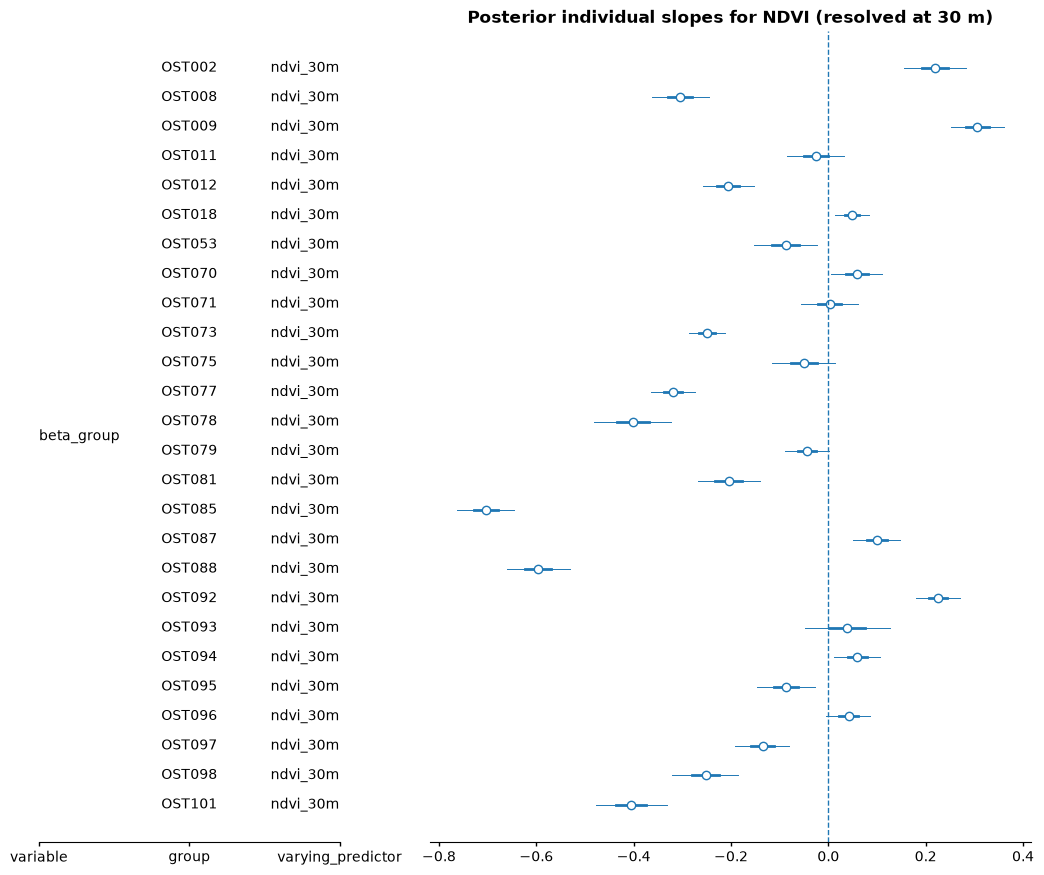

In [75]:
az.plot_forest(
    idata_hierarchical,
    var_names=["beta_group"],
    combined=True,
)

plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Posterior individual slopes for NDVI (resolved at 30 m)", fontsize=12, fontweight="semibold")
plt.savefig("../../docs/figures-for-doc/posterior_individual_slopes_ndvi.png", dpi=300, bbox_inches="tight")
plt.show()